Packages
---

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import scipy.optimize as op
import ising

Loading dataset
---

Loaded 300 files with their corresponding beta and h values.
First file parameters -> Beta: 0.001, H: 0.0
x_train_flat shape: (300, 40000)
y_train shape: (300,)


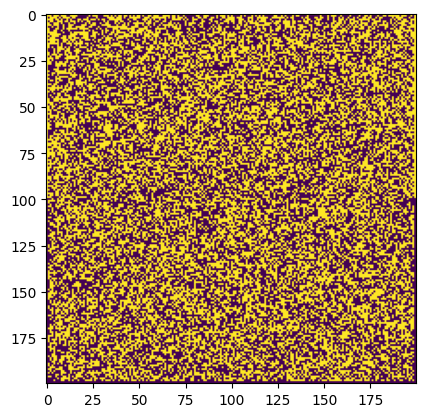

In [2]:


# Find all .npz files in the data directory
file_pattern = "../2dIsingData/zero_h/*.npz"
all_files = glob.glob(file_pattern)

dataset_list = []

for file_path in all_files:
    # 1. Strip away the folder path ("data/") and the extension (".npz")
    # Example: "data/0.44_0.0_above_2026..." -> "0.44_0.0_above_2026..."
    base_name = os.path.basename(file_path).replace(".npz", "")
    
    # 2. Split the string by underscores
    # Parts will look like: ["0.44", "0.0", "above", "20260522", "092547", "123456"]
    parts = base_name.split("_")
    
    # 3. Extract and convert beta and h from their positions in the filename
    beta_val = float(parts[0])
    h_val = float(parts[1])
    criticality = True
    if(parts[2] == "above"):
        pass
    else:
        criticality = False


    
    # 4. Load the actual arrays from inside the file
    with np.load(file_path) as data:
        dataset_list.append({
            "filename": file_path,
            "beta": beta_val,
            "h": h_val,
            "sigma": data['sigma'],
            "phase": str(data['phase']),
            "criticality": criticality
        })

print(f"Loaded {len(dataset_list)} files with their corresponding beta and h values.")

# Example: Inspecting the parameters of the first loaded file
print(f"First file parameters -> Beta: {dataset_list[0]['beta']}, H: {dataset_list[0]['h']}")

# Test
plt.imshow(dataset_list[0]['sigma'])

#Formatting for training
# 1. Extract and flatten each individual sigma matrix
# This creates a 2D array of shape (num_samples, num_features)
x_train_flat = np.array([sample['sigma'].flatten() for sample in dataset_list])

# 2. Extract the criticality booleans/labels
# This creates a 1D array of shape (num_samples,)
y_train = np.array([sample['criticality'] for sample in dataset_list])

# Verification check
print("x_train_flat shape:", x_train_flat.shape)
print("y_train shape:", y_train.shape)

Training for the case of h = 0
---

In [3]:
N = 200
INPUT_SHAPE = N * N
BATCH_SIZE = 32
EPOCHS = 25

def build_ising_model(input_dim):
    model = models.Sequential([
        # Flatten the n x n grid into a 1D vector
        layers.Input(shape=(input_dim,)),
        
        # Hidden Layer 1
        layers.Dense(64, activation='relu'),
        
        # Hidden Layer 2
        layers.Dense(32, activation='relu'),
        
        # Output Layer: Sigmoid squashes output to range [0, 1]
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_ising_model(INPUT_SHAPE)
model.summary()

history = model.fit(
    x_train_flat, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.4
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │     2,560,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,562,177 (9.77 MB)

 Trainable params: 2,562,177 (9.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.8333 - loss: 1.8624 - val_accuracy: 1.0000 - val_loss: 7.7837e-10
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8222 - loss: 1.5280 - val_accuracy: 0.0000e+00 - val_loss: 21.0379
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8778 - loss: 1.4287 - val_accuracy: 1.0000 - val_loss: 1.3439e-10
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9000 - loss: 0.8311 - val_accuracy: 0.0000e+00 - val_loss: 5.2336
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9556 - loss: 0.3782 - val_accuracy: 1.0000 - val_loss: 2.2327e-09
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9000 - loss: 0.8029 - val_accuracy: 1.0000 - val_loss: 6.5827e-04
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9667 - loss: 0.2106 - val_accuracy: 1.0000 - val_loss: 5.1884e-13
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9667 - loss: 0.2166 - val_accurac

Visualizing the critical temperature using the model
---

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


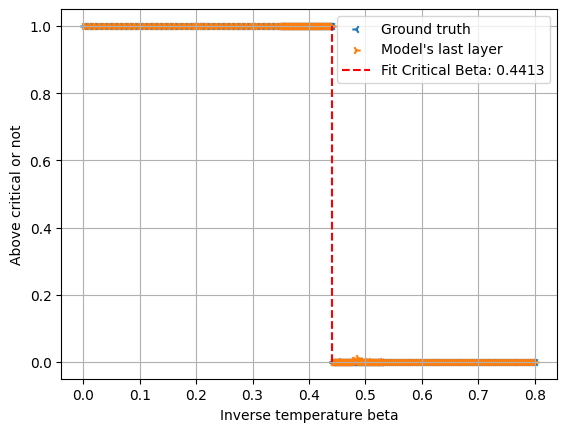

In [4]:
def smooth_crit_temp(beta, a, k=50):
    return 1 / (1 + np.exp(k * (beta - a)))

betas = np.array([sample['beta'] for sample in dataset_list])
criticalities = np.array([sample['criticality'] for sample in dataset_list])
predictions = model.predict(x_train_flat)

plt.scatter(betas, criticalities, label='Ground truth', marker = '3')
plt.scatter(betas, predictions, label='Model\'s last layer', marker = '4')
popt, pcov = op.curve_fit(smooth_crit_temp, betas, predictions.flatten(), p0=[0.3])
plt.vlines(popt[0], 0, 1, colors='r', linestyles='dashed', label=f'Fit Critical Beta: {popt[0]:.4f}')
plt.xlabel("Inverse temperature beta")
plt.ylabel("Above critical or not")
plt.grid(True)
plt.legend()
plt.show()

Though the model saw 60% of labels for these matrices, the resulting beta is in good agreement with the value listed on wikipedia: 0.4406867

Fitting to subsets of spin grids, determining beta from predicting fresh data (h = 0 case)
---

In [5]:
# Define your crop size
m = 150

def random_crop(matrix, size):
    h, w = matrix.shape
    # Calculate the maximum valid starting indices to prevent out-of-bounds errors
    max_h = h - size
    max_w = w - size
    
    # Pick random starting coordinates
    start_h = np.random.randint(0, max_h + 1)
    start_w = np.random.randint(0, max_w + 1)
    
    return matrix[start_h : start_h + size, start_w : start_w + size]

# Find all .npz files in the data directory
file_pattern = "../2dIsingData/zero_h/*.npz"
all_files = glob.glob(file_pattern)

dataset_list = []

for file_path in all_files:
    # 1. Strip away the folder path ("data/") and the extension (".npz")
    base_name = os.path.basename(file_path).replace(".npz", "")
    
    # 2. Split the string by underscores
    parts = base_name.split("_")
    
    # 3. Extract and convert beta and h from their positions in the filename
    beta_val = float(parts[0])
    h_val = float(parts[1])
    criticality = True
    if(parts[2] == "above"):
        pass
    else:
        criticality = False

    # 4. Load the actual arrays from inside the file
    with np.load(file_path) as data:
        dataset_list.append({
            "filename": file_path,
            "beta": beta_val,
            "h": h_val,
            "sigma": data['sigma'],
            "phase": str(data['phase']),
            "criticality": criticality
        })
# Formatting for training

x_train_flat = np.array([random_crop(sample['sigma'], m).flatten() for sample in dataset_list])
y_train = np.array([sample['criticality'] for sample in dataset_list])
betas = np.array([sample['beta'] for sample in dataset_list])

#Fit the model to the unforgiving data
model = build_ising_model(m*m)
model.summary()

history = model.fit(
    x_train_flat, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.05 #We will be doing ample validation with a separate dataset
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │     1,440,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,442,177 (5.50 MB)

 Trainable params: 1,442,177 (5.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5474 - loss: 2.0704 - val_accuracy: 0.4000 - val_loss: 3.6010
Epoch 2/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7684 - loss: 1.1144 - val_accuracy: 1.0000 - val_loss: 0.0022
Epoch 3/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8877 - loss: 0.5665 - val_accuracy: 0.4000 - val_loss: 1.7846
Epoch 4/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9684 - loss: 0.1068 - val_accuracy: 1.0000 - val_loss: 0.0070
Epoch 5/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9860 - loss: 0.0696 - val_accuracy: 1.0000 - val_loss: 0.0283
Epoch 6/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9965 - loss: 0.0125 - val_accuracy: 1.0000 - val_loss: 3.9482e-04
Epoch 7/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9965 - loss: 0.0106 - val_accuracy: 1.0000 - val_loss: 0.0012
Epoch 8/25
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 1.0000 - val_loss: 3.2

In [6]:
#As convergence indeed slows with decreasing m, we generate supplementary data to predict on
new_betas = np.linspace(0, 1, 100)
x_train_flat_new = 0
for beta in new_betas:
    generator = ising.Ising(0, beta, N)
    generator.generate()
    if(beta == 0):
        x_train_flat_new = random_crop(generator.sigma, m).flatten()
    else:
        x_train_flat_new = np.column_stack((x_train_flat_new, random_crop(generator.sigma, m).flatten()))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


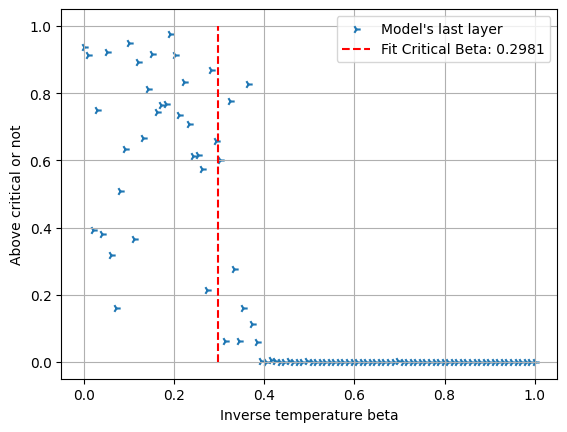

In [7]:
x_train_flat_new = x_train_flat_new.T
predictions = model.predict(x_train_flat_new)
plt.scatter(new_betas, predictions.flatten(), label='Model\'s last layer', marker = '4')
popt, pcov = op.curve_fit(smooth_crit_temp, new_betas, predictions.flatten(), p0=[0.4])
plt.vlines(popt[0], 0, 1, colors='r', linestyles='dashed', label=f'Fit Critical Beta: {popt[0]:.4f}')
plt.xlabel("Inverse temperature beta")
plt.ylabel("Above critical or not")
plt.grid(True)
plt.legend()
plt.show()

The result of predicting on fresh, randomly positioned subsets is weak. This could indicate that the model was relying on features belonging to certain weights, such as the middle boundary, or the frame always being in the same place. Interestingly subcritical recognition wasn't hurt nearly as much as supercritical, but its interval also starts expanding upwards.

Throwing parameters at the problem
---

In [ ]:
EPOCHS = 10
def build_ising_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(int(input_dim/2), activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    return model

model = build_ising_model(m*m)
model.summary()

history = model.fit(
    x_train_flat, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.05
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 11250)          │   253,136,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       720,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 253,858,427 (968.39 MB)

 Trainable params: 253,858,427 (968.39 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.5789 - loss: 13.3921 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.7298 - loss: 10.7340 - val_accuracy: 1.0000 - val_loss: 1.5837e-15
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8351 - loss: 2.8096 - val_accuracy: 0.4000 - val_loss: 6.6818
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.8561 - loss: 2.2674 - val_accuracy: 1.0000 - val_loss: 9.8141e-16
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9298 - loss: 1.4577 - val_accuracy: 1.0000 - val_loss: 1.9412e-05
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9754 - loss: 0.3312 - val_accuracy: 0.3333 - val_loss: 6.5762
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9368 - loss: 0.8274 - val_accuracy: 1.0000 - val_loss: 4.7035e-09
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.9860 - loss: 0.0386 - val_accuracy: 1.0000 - val

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/stepWARNING:tensorflow:6 out of the last 18 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001B9CFF07C40> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step


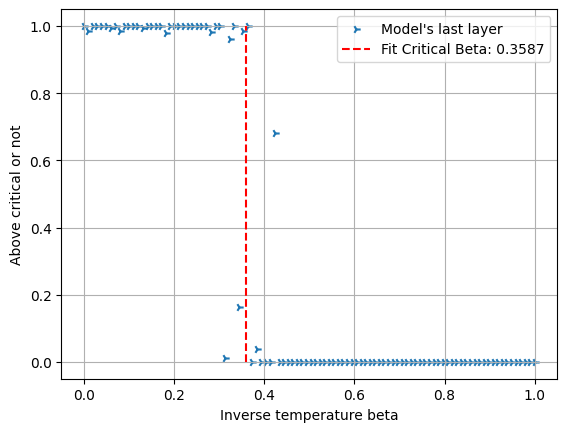

In [ ]:
x_train_flat_new = 0
for beta in new_betas:
    generator = ising.Ising(0, beta, N)
    generator.generate()
    if(beta == 0):
        x_train_flat_new = random_crop(generator.sigma, m).flatten()
    else:
        x_train_flat_new = np.column_stack((x_train_flat_new, random_crop(generator.sigma, m).flatten()))

x_train_flat_new = x_train_flat_new.T
predictions = model.predict(x_train_flat_new)
plt.scatter(new_betas, predictions.flatten(), label='Model\'s last layer', marker = '4')
popt, pcov = op.curve_fit(smooth_crit_temp, new_betas, predictions.flatten(), p0=[0.4])
plt.vlines(popt[0], 0, 1, colors='r', linestyles='dashed', label=f'Fit Critical Beta: {popt[0]:.4f}')
plt.xlabel("Inverse temperature beta")
plt.ylabel("Above critical or not")
plt.grid(True)
plt.legend()
plt.show()

Note, the model doesn't appear to converge every time, please run untill step function appears with shifted phase-transition

The model with dramatically more parameters remarkably appears to converge to the same place as did the smaller one. The perceived phase transition is shifted to a higher temperature. This result can be interpreted as the submatrices containing less total structure due to their inherently decreased size, this appears as increased disorder/temperature, and the model is therefore confidently wrong. Though the phase transition appears to be only measurable on complete spin grids, we did succeed in having the FCNN learn patterns that were not related to the position of weights in relation to the data, but their relation.
This discussion was influenced by Gemini, which can be read through the following link: [text](https://gemini.google.com/share/c3af6818e43d)